# Експеримент 05: SVM для класифікації тем без категорії "новини" (ExpB)

## Мета
Дослідити вплив видалення загальної категорії "новини" на продуктивність класифікатора.

## Гіпотеза
Видалення найменш специфічної категорії "новини" може покращити розділюваність інших класів.

In [1]:
# Імпорт бібліотек
import os
import sys
import json
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import pymorphy3
import re

# # # # sys.path.append('..')  # Not needed  # Not needed  # Not needed  # Not needed
from utils.experiment_utils import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Шляхи
dataset_path = r"C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\theme_detector\ua_news_train_balanced.csv"
models_dir = 'saved_models/'
plots_dir = 'plots/'
results_dir = 'results/'

assert os.path.exists(dataset_path), f"Датасет не знайдено: {dataset_path}"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print("Середовище підготовлено")

Середовище підготовлено


## 1. Завантаження та фільтрація даних

In [3]:
df = pd.read_csv(dataset_path)
print(f"Повний датасет: {df.shape}")
print(f"Розподіл:\n{df['target'].value_counts()}")

# Видалення категорії "новини"
df_filtered = df[df['target'] != 'новини'].copy()
df_filtered.reset_index(drop=True, inplace=True)

print(f"\n=== Після видалення 'новини' ===")
print(f"Розмір: {df_filtered.shape}")
print(f"Розподіл:\n{df_filtered['target'].value_counts()}")

Повний датасет: (50000, 4)
Розподіл:
target
політика      10000
спорт         10000
новини        10000
технології    10000
бізнес        10000
Name: count, dtype: int64

=== Після видалення 'новини' ===
Розмір: (40000, 4)
Розподіл:
target
політика      10000
спорт         10000
технології    10000
бізнес        10000
Name: count, dtype: int64


## 2. Препроцесинг (ідентичний до Exp 04)

In [6]:
with open('C:/Users/igrew/OneDrive/Desktop/Course Work/stopwords_ua.txt', 'r', encoding='utf-8') as f:
    ukrainian_stopwords  = set(f.read().splitlines())


morph = pymorphy3.MorphAnalyzer(lang='uk')

lemma_cache = {}

def preprocess_text(sentence):
    words = sentence.split()
    lemmas = []
    for word in words:
        if word not in lemma_cache:
            lemma_cache[word] = morph.parse(word)[0].normal_form
        lemmas.append(lemma_cache[word])
    return ' '.join(lemmas)

# Застосування препроцесингу
print("Препроцесинг текстів...")
df_filtered['text_processed'] = [preprocess_text(text) for text in tqdm(df_filtered['text'], desc="Preprocessing")]
print("Препроцесинг завершено")

Препроцесинг текстів...


Preprocessing:   0%|          | 0/40000 [00:00<?, ?it/s]

Препроцесинг завершено


## 3. Розбиття на train/test

In [7]:
# Підготовка даних
X = df_filtered['text_processed'].values
y = df_filtered['target'].values

# Розбиття 80/20 зі стратифікацією
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nTrain розподіл:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")
print(f"\nTest розподіл:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

Train: 32000 | Test: 8000

Train розподіл:
  бізнес: 8000
  політика: 8000
  спорт: 8000
  технології: 8000

Test розподіл:
  бізнес: 2000
  політика: 2000
  спорт: 2000
  технології: 2000


## 4. Векторизація TF-IDF

In [8]:
# TF-IDF з біграмами (ті ж параметри що в Base)
vectorizer = TfidfVectorizer(
    max_features=30000,  
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,  
    use_idf=True,
    smooth_idf=True
)

print("Векторизація...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

Векторизація...
Train shape: (32000, 30000)
Test shape: (8000, 30000)


## 5. Тренування LinearSVC

In [9]:
# Тренування моделі (ті ж гіперпараметри)
print("Тренування LinearSVC...")
base_svm = LinearSVC(random_state=SEED, max_iter=2000, dual=False)
model = CalibratedClassifierCV(base_svm, cv=3)
model.fit(X_train_tfidf, y_train)
print("Тренування завершено")

Тренування LinearSVC...
Тренування завершено


## 6. Оцінка моделі

In [10]:
# Передбачення
y_pred = model.predict(X_test_tfidf)

# Метрики
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
per_class_f1 = f1_score(y_test, y_pred, average=None)

print("=" * 50)
print("РЕЗУЛЬТАТИ SVM ExpB (4 класи)")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

classes = np.unique(y_train)
print(f"\nF1-score по класам:")
for cls, f1 in zip(classes, per_class_f1):
    print(f"  {cls}: {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=classes))

РЕЗУЛЬТАТИ SVM ExpB (4 класи)
Accuracy: 0.9675
Macro-F1: 0.9675
Weighted-F1: 0.9675

F1-score по класам:
  бізнес: 0.9429
  політика: 0.9633
  спорт: 0.9940
  технології: 0.9699

=== Classification Report ===
              precision    recall  f1-score   support

      бізнес       0.94      0.95      0.94      2000
    політика       0.98      0.95      0.96      2000
       спорт       0.99      1.00      0.99      2000
  технології       0.97      0.97      0.97      2000

    accuracy                           0.97      8000
   macro avg       0.97      0.97      0.97      8000
weighted avg       0.97      0.97      0.97      8000



In [11]:
y_pred_train = model.predict(X_train_tfidf)
accuracy_train = accuracy_score(y_train, y_pred_train)
macro_f1_train = f1_score(y_train, y_pred_train, average='macro')

print(f"Train Accuracy: {accuracy_train:.4f}")
print(f"Train Macro-F1: {macro_f1_train:.4f}")
print(f"Test  Accuracy: {accuracy:.4f}")
print(f"Test  Macro-F1: {macro_f1:.4f}")
print(f"Різниця (overfit check): {accuracy_train - accuracy:.4f}")

Train Accuracy: 0.9975
Train Macro-F1: 0.9975
Test  Accuracy: 0.9675
Test  Macro-F1: 0.9675
Різниця (overfit check): 0.0300


## 7. Візуалізація: Confusion Matrix 4x4

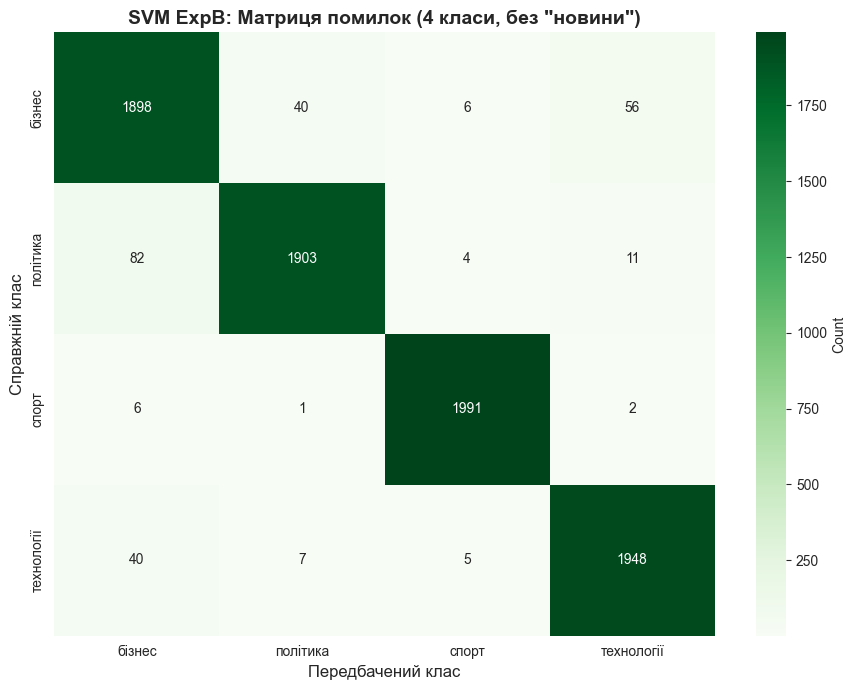

In [12]:
# Матриця помилок
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Count'})
plt.xlabel('Передбачений клас', fontsize=12)
plt.ylabel('Справжній клас', fontsize=12)
plt.title('SVM ExpB: Матриця помилок (4 класи, без "новини")', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}05_topic_svm_expB_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 8. Візуалізація: F1-score по класах

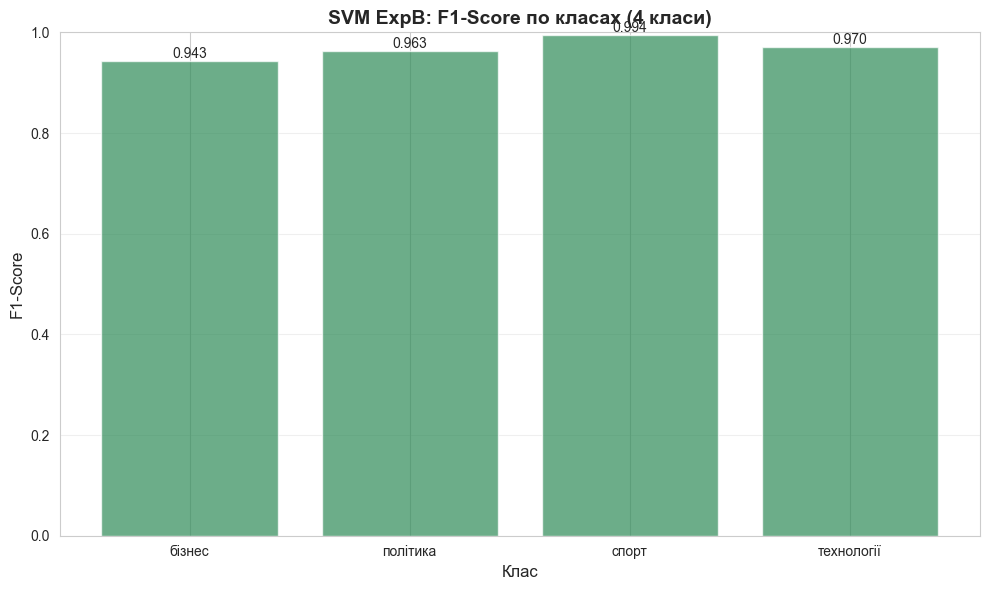

In [13]:
# F1-score барплот
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, per_class_f1, color='seagreen', alpha=0.7)
plt.xlabel('Клас', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('SVM ExpB: F1-Score по класах (4 класи)', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)

for bar, val in zip(bars, per_class_f1):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{plots_dir}05_topic_svm_expB_f1_per_class.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 9. Порівняння Base vs ExpB

Baseline результати завантажено


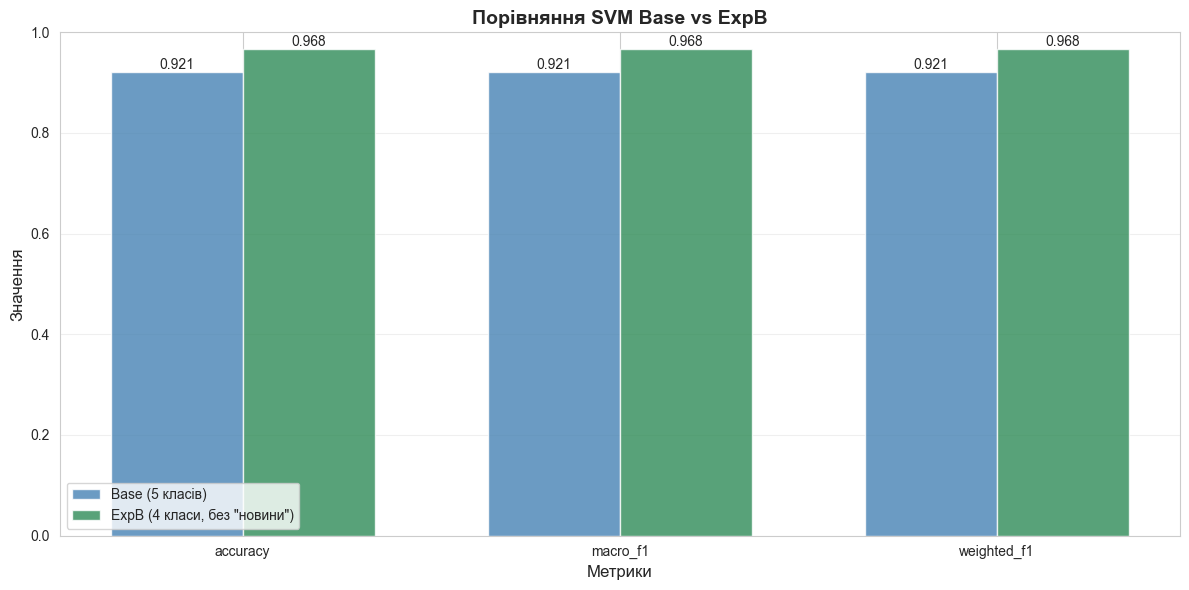

In [14]:
# Завантаження результатів Base
with open(f'{results_dir}04_topic_svm_base_results.json', 'r') as f:
    metrics_base = json.load(f)

print("Baseline результати завантажено")

# Порівняльний графік
fig, ax = plt.subplots(figsize=(12, 6))

metric_names = ['accuracy', 'macro_f1', 'weighted_f1']
base_values = [metrics_base[m] for m in metric_names]
expB_values = [accuracy, macro_f1, weighted_f1]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, base_values, width, label='Base (5 класів)', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, expB_values, width, label='ExpB (4 класи, без "новини")', alpha=0.8, color='seagreen')

ax.set_xlabel('Метрики', fontsize=12)
ax.set_ylabel('Значення', fontsize=12)
ax.set_title('Порівняння SVM Base vs ExpB', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{plots_dir}05_topic_svm_base_vs_expB.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 10. Збереження результатів

In [15]:
# Збереження моделі та векторизатора
with open(f'{models_dir}topic_svm_expB_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{models_dir}topic_svm_expB_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Збереження метрик
metrics = {
    'accuracy': float(accuracy),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_f1': {cls: float(f1) for cls, f1 in zip(classes, per_class_f1)}
}

with open(f'{results_dir}05_topic_svm_expB_results.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("=== Результати збережено ===")
print(f"Модель: {models_dir}topic_svm_expB_model.pkl")
print(f"Векторизатор: {models_dir}topic_svm_expB_vectorizer.pkl")
print(f"Результати: {results_dir}05_topic_svm_expB_results.json")

=== Результати збережено ===
Модель: saved_models/topic_svm_expB_model.pkl
Векторизатор: saved_models/topic_svm_expB_vectorizer.pkl
Результати: results/05_topic_svm_expB_results.json


## 11. Висновки

Експеримент ExpB показує вплив видалення категорії "новини" на класифікацію.

Можливі результати:
- Підвищення метрик через видалення найменш специфічної категорії
- Краще розділення між специфічними темами (політика, спорт, технології, бізнес)
- Порівняння з Base допомагає зрозуміти, наскільки категорія "новини" була джерелом confusion